In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from visualization import plot_throughput
import seaborn as sns

In [46]:
df = pd.read_csv("sim_events.csv")
df.head()

,timestamp,event_type,task_id,gpu_id,npts
0,0,START,78,1,12552648
1,0,START,23,1,7830895
2,0,START,1,2,12550781
3,0,START,4,2,7503288
4,0,START,151,3,12550654


In [47]:
task_stats = df.groupby('task_id').agg(
    npts = ('npts','sum'),
    start_time = ('timestamp','min'),
    finish_time = ('timestamp',lambda x: x[df.loc[x.index,'event_type']=='FINISH'].max()),
    interruptions=('event_type', lambda x: (x == 'INTERRUPT').sum())
).dropna()
task_stats['duration'] = (task_stats['finish_time'] - task_stats['start_time']) / 1000.0

In [48]:
task_stats.head()

,npts,start_time,finish_time,interruptions,duration
task_id,,,,,
0,17454394,219000,365000,0,146.0
1,25101562,0,239000,0,239.0
2,125429300,0,737000,4,737.0
3,25094606,0,224000,0,224.0
4,15006576,0,134000,0,134.0


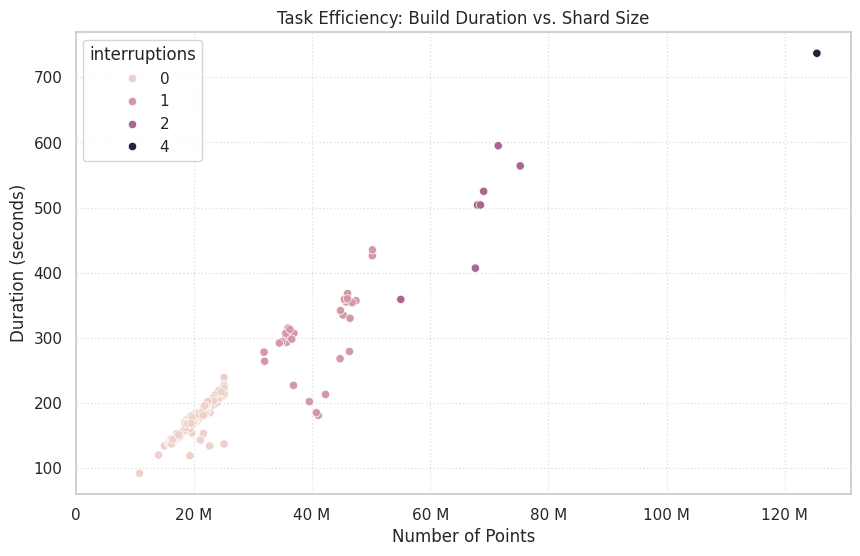

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=task_stats,x='npts',y='duration',hue='interruptions')
plt.gca().xaxis.set_major_formatter(ticker.EngFormatter())
plt.xlim(left=0)
plt.title('Task Efficiency: Build Duration vs. Shard Size')
plt.xlabel('Number of Points')
plt.ylabel('Duration (seconds)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [45]:
starts = df[df['event_type'] == 'START'][['timestamp']].copy()
starts['change'] = 1
ends = df[df['event_type'].isin(['FINISH', 'INTERRUPT'])][['timestamp']].copy()
ends['change'] = -1
concurrency = pd.concat([starts, ends]).sort_values('timestamp')
concurrency['active_tasks'] = concurrency['change'].cumsum()

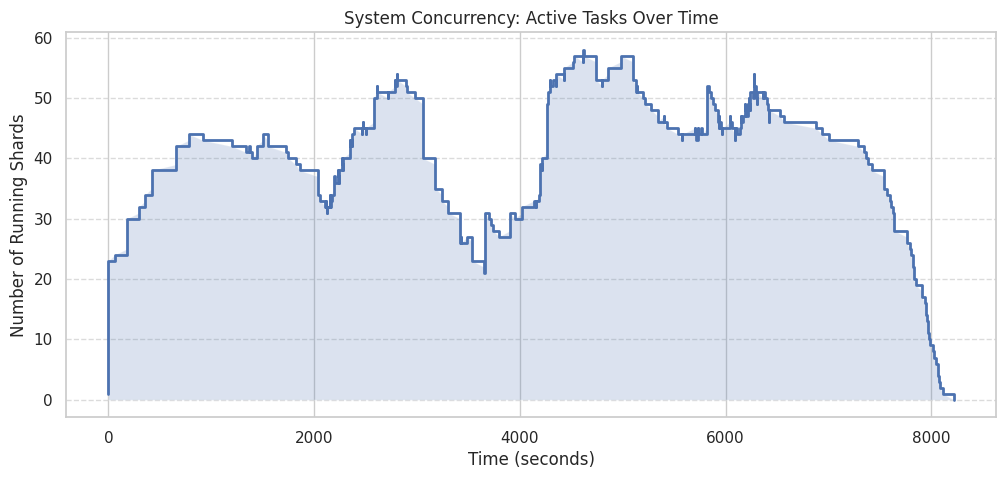

In [50]:
plt.figure(figsize=(12, 5))
plt.step(concurrency['timestamp'] / 1000, concurrency['active_tasks'], where='post', lw=2)
plt.fill_between(concurrency['timestamp'] / 1000, concurrency['active_tasks'], alpha=0.2)
plt.title('System Concurrency: Active Tasks Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Number of Running Shards')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

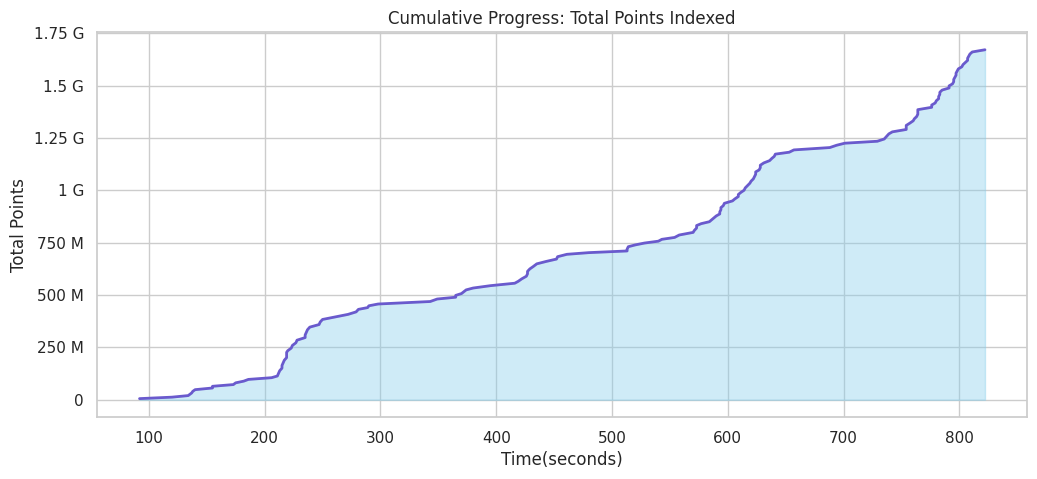

In [51]:
progress = df[df['event_type']=='FINISH'].sort_values('timestamp').copy()
progress['cumulative_points'] = progress['npts'].cumsum()

plt.figure(figsize=(12, 5))
plt.fill_between(progress['timestamp'] / 1000, progress['cumulative_points'], color='skyblue', alpha=0.4)
plt.plot(progress['timestamp'] / 1000, progress['cumulative_points'], color='Slateblue', lw=2)

plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Cumulative Progress: Total Points Indexed')
plt.xlabel('Time(seconds)')
plt.ylabel('Total Points')
plt.show()

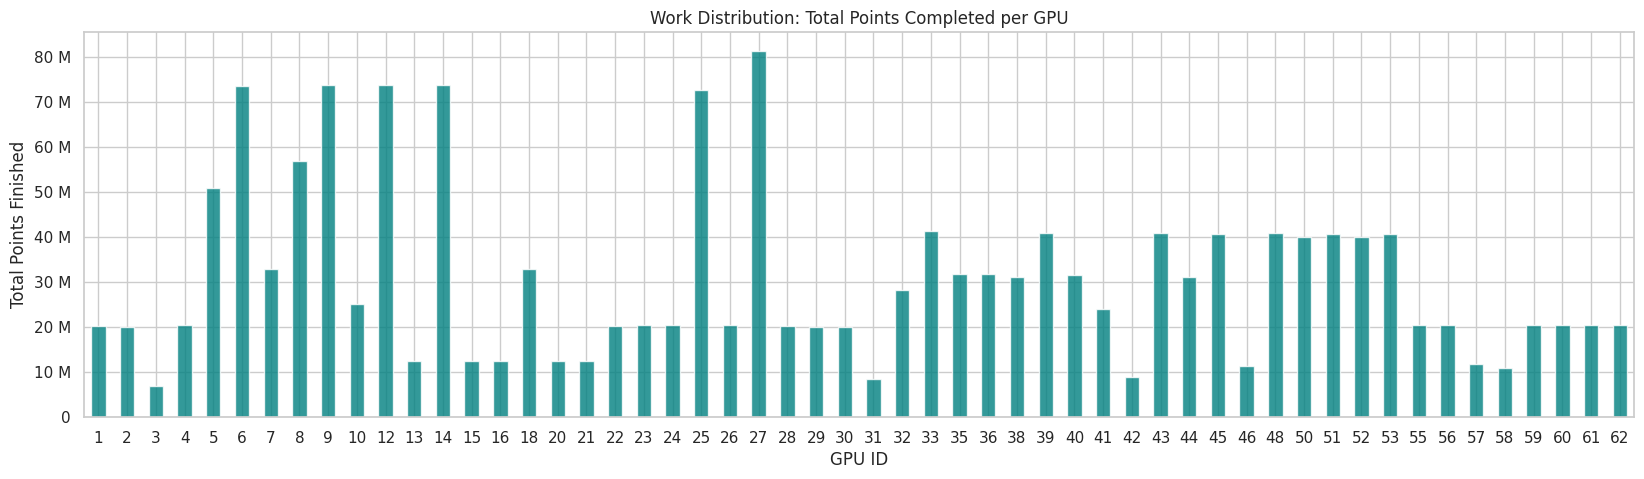

In [52]:
gpu_work = df[df['event_type'] == 'FINISH'].groupby('gpu_id')['npts'].sum().sort_index()
plt.figure(figsize=(20,5))
gpu_work.plot(kind='bar',color='teal',alpha=0.8)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.title('Work Distribution: Total Points Completed per GPU')
plt.xlabel('GPU ID')
plt.ylabel('Total Points Finished')
plt.xticks(rotation=0)
plt.show()